In [1]:
import pathlib, re, tifffile, numpy as np, pandas as pd
from liffile import LifFile
from skimage.restoration import rolling_ball
import matplotlib.pyplot as plt

In [2]:
def _step(axis, xa):
    if axis not in xa.coords or xa.coords[axis].size < 2:
        return None
    return float(xa.coords[axis][1] - xa.coords[axis][0])

In [3]:

src_root = pathlib.Path(r"Z:\Bel\Farid_calcium")
out_root = pathlib.Path(r"Z:\Bel\Farid_calcium\tifs")
out_root.mkdir(parents=True, exist_ok=True)

ROLLING_BALL_RADII = [10, 50]  # pixels


def _safe(name):
    """Make a string safe to use in a filename."""
    return re.sub(r"[^\w.\-]+", "_", str(name)).strip("_")


def _reorder_tzyx(data, dims):
    """Reorder a LIF array to (T, Z, Y, X), collapsing channels (keep ch 0)."""
    dims = list(dims)
    order = [d for d in ("T", "Z", "C", "Y", "X") if d in dims]
    order += [d for d in dims if d not in order]
    data = np.transpose(data, [dims.index(d) for d in order])
    dims = order
    if "C" in dims:                       # single-channel calcium → keep channel 0
        ci = dims.index("C")
        data = data[(slice(None),) * ci + (0,)]
        dims.pop(ci)
    return data, dims                     # data is (T, Z, Y, X) when both T and Z present


def _rolling_ball_stack(stack4d, radius):
    """Apply rolling-ball background subtraction to a (T, Z, Y, X) stack, per Z plane."""
    out = np.empty_like(stack4d, dtype=np.float32)
    for t in range(stack4d.shape[0]):
        for z in range(stack4d.shape[1]):
            frame = stack4d[t, z].astype(np.float32)
            out[t, z] = np.clip(frame - rolling_ball(frame, radius=radius), 0, None)
    return out


def _save_imagej(path, stack4d, x_um, z_um):
    """Save a (T, Z, Y, X) stack as an ImageJ hyperstack with calibration."""
    resolution = (1.0 / x_um, 1.0 / x_um) if x_um else None
    metadata = {"axes": "TZYX", "unit": "um"}
    if z_um:
        metadata["spacing"] = z_um
    tifffile.imwrite(str(path), stack4d, imagej=True,
                     resolution=resolution, metadata=metadata)


lif_paths = sorted(src_root.rglob("*.lif"))
print(f"Found {len(lif_paths)} LIF files\n")

for lif_path in lif_paths:
    lif_stem = lif_path.stem
    with LifFile(lif_path) as lif:
        for img in lif.images:
            image_name = "".join(img.path)
            dims = tuple(img.dims)

            # Only process stacks with a real time axis (>1 timepoint)
            if "T" not in dims or img.shape[dims.index("T")] < 2:
                continue
            if "Z" not in dims:  # need 4D x,y,z,t
                continue

            data, new_dims = _reorder_tzyx(img.asarray(), dims)  # (T, Z, Y, X)

            xa = img.asxarray()
            x_um = _step("X", xa) * 1e6 if _step("X", xa) is not None else None
            z_um = _step("Z", xa) * 1e6 if _step("Z", xa) is not None else None

            base = f"{_safe(lif_stem)}__{_safe(image_name)}"
            print(f"{lif_path.name} :: {image_name}  shape={data.shape}  x={x_um}µm z={z_um}µm")

            # 1) original
            _save_imagej(out_root / f"{base}_original.tif", data, x_um, z_um)

            # 2) rolling-ball variants
            for radius in ROLLING_BALL_RADII:
                bg = _rolling_ball_stack(data, radius)
                _save_imagej(out_root / f"{base}_rolling_ball_{radius}.tif", bg, x_um, z_um)
                print(f"    saved rolling_ball_{radius}")

print("\nDone.")


Found 4 LIF files

18.05.26 fluo8 reservoir 1.lif :: Reservoir 1 1ul_min 10min  shape=(9, 36, 512, 512)  x=2.271256360078278µm z=4.886154285714285µm
    saved rolling_ball_10
    saved rolling_ball_50
18.05.26 fluo8 reservoir 1.lif :: Reservoir 1 4ul_min 10min  shape=(9, 36, 512, 512)  x=2.271256360078278µm z=-5.000119999999995µm
    saved rolling_ball_10
    saved rolling_ball_50
18.05.26 fluo8 reservoir 1.lif :: Reservoir 1 0ul_min 10 min  shape=(9, 36, 512, 512)  x=2.271256360078278µm z=5.000117142857168µm
    saved rolling_ball_10
    saved rolling_ball_50
18.05.26 fluo8 reservoir 1.lif :: Reservoir 1 4ul_min round 2 10min  shape=(9, 36, 512, 512)  x=2.271256360078278µm z=5.000119999999995µm
    saved rolling_ball_10
    saved rolling_ball_50
18.05.26 fluo8 reservoir 1.lif :: Reservoir 1 8ul_min 10min  shape=(9, 36, 512, 512)  x=2.271256360078278µm z=5.000119999999995µm
    saved rolling_ball_10
    saved rolling_ball_50
18.05.26 Fluo8 reservoir 5.lif :: Reservoir 5 1ul_min 10min  

In [ ]:






# ── Normalise a LIF array to (T, Z, Y, X) ────────────────────────────────────
def _to_tzyx(data, dims):
    """Reorder a LIF array to (T, Z, Y, X); collapse channels, add missing T/Z."""
    dims = list(dims)
    order = [d for d in ("T", "Z", "C", "Y", "X") if d in dims]
    order += [d for d in dims if d not in order]          # keep any extra axes last
    data = np.transpose(data, [dims.index(d) for d in order])
    dims = order
    if "C" in dims:                                       # single-channel calcium → keep channel 0
        ci = dims.index("C")
        data = data[(slice(None),) * ci + (0,)]
        dims.pop(ci)
    if "T" not in dims:                                   # single timepoint
        data, dims = data[np.newaxis], ["T"] + dims
    if "Z" not in dims:                                   # 2D frames → singleton Z
        data, dims = data[:, np.newaxis], [dims[0], "Z"] + dims[1:]
    return data                                           # (T, Z, Y, X)

# ── Yield (sub_label, data) for a TIF (one stack) or LIF (one per image) ──────
def iter_stacks(path):
    if path.suffix.lower() == ".lif":
        with LifFile(path) as lif:
            for img in lif.images:
                label = "".join(img.path).replace("/", "_")
                try:
                    data = img.asarray()
                except Exception as e:
                    print(f"  SKIP {label}: cannot read ({type(e).__name__}: {e})")
                    continue
                yield label, _to_tzyx(data, tuple(img.dims))
    else:
        yield None, tifffile.imread(str(path))

def _file_label(path, sub_label):
    return path.name if sub_label is None else f"{path.name}::{sub_label}"

# ── Extract reservoir number & flow rate from a label ────────────────────────
def _extract_reservoir(label):
    """'... Reservoir 1 1ul_min ...' → 1  (matches 'reservoir' or 'resevoir')."""
    m = re.search(r"reser?voir\s*(\d+)", label, re.IGNORECASE)
    return int(m.group(1)) if m else None

def _extract_round(label):
    """'... Round 2 ...' or '... round2 ...' → 2; default 1 if absent."""
    m = re.search(r"round\s*(\d+)", label, re.IGNORECASE)
    return int(m.group(1)) if m else 1

def _extract_flow_rate(label):
    """'1ul_min' / '4ul_min' / '0ul_min' → 1 / 4 / 0 (µl/min)."""
    m = re.search(r"(\d+)\s*ul[\s_]*min", label, re.IGNORECASE)
    return int(m.group(1)) if m else None


root = pathlib.Path(r"Z:\Bel\Farid_calcium")

image_paths = [p for p in sorted([*root.rglob("*.tif"), *root.rglob("*.lif")])]
n_tif = sum(p.suffix.lower() == ".tif" for p in image_paths)
n_lif = sum(p.suffix.lower() == ".lif" for p in image_paths)
print(f"Found {n_tif} TIF and {n_lif} LIF files\n")

for p in image_paths:
    for sub_label, data in iter_stacks(p):
        file_label = _file_label(p, sub_label)
        if data.ndim not in (3, 4):
            print(f"  SKIP unexpected shape {data.shape}: {file_label}")
            continue
        reservoir = _extract_reservoir(file_label)
        flow_rate = _extract_flow_rate(file_label)
        round = _extract_round(file_label)
        n_frames = data.shape[0]




            for t in range(n_frames):  # timepoint resets per image: 0, 1, 2, ...
                rows.append({
                    "condition": condition,
                    "file": file_label,
                    "reservoir": reservoir,
                    "flow_rate": flow_rate,
                    "round": round,
                    "timepoint": t,
                    "sum_intensity": int(data[t].sum()),
                })
            print(f"  {file_label}  shape={data.shape}  frames={n_frames}  "
                  f"reservoir={reservoir}  flow={flow_rate}ul/min  round={round}")

df = pd.DataFrame(rows)

# ── Save CSV ─────────────────────────────────────────────────────────────────
out_csv = root / "sum_intensity_per_timepoint.csv"
df.to_csv(out_csv, index=False)
print(f"\nSaved {len(df)} rows to:\n  {out_csv}")
df


Found 0 TIF and 4 LIF files

── Bel / Farid_calcium (4 files) ──
  18.05.26 fluo8 reservoir 1.lif::Reservoir 1 1ul_min 10min  shape=(9, 36, 512, 512)  frames=9  reservoir=1  flow=1ul/min  round=1
  18.05.26 fluo8 reservoir 1.lif::Reservoir 1 4ul_min 10min  shape=(9, 36, 512, 512)  frames=9  reservoir=1  flow=4ul/min  round=1
  18.05.26 fluo8 reservoir 1.lif::Reservoir 1 0ul_min 10 min  shape=(9, 36, 512, 512)  frames=9  reservoir=1  flow=0ul/min  round=1
  18.05.26 fluo8 reservoir 1.lif::Reservoir 1 4ul_min round 2 10min  shape=(9, 36, 512, 512)  frames=9  reservoir=1  flow=4ul/min  round=2
  18.05.26 fluo8 reservoir 1.lif::Reservoir 1 8ul_min 10min  shape=(9, 36, 512, 512)  frames=9  reservoir=1  flow=8ul/min  round=1
  18.05.26 Fluo8 reservoir 5.lif::Reservoir 5 1ul_min 10min  shape=(10, 43, 512, 512)  frames=10  reservoir=5  flow=1ul/min  round=1
  18.05.26 Fluo8 reservoir 5.lif::Reservoir 5 4ul_min 10min  shape=(10, 43, 512, 512)  frames=10  reservoir=5  flow=4ul/min  round=1
  18.

,condition,file,reservoir,flow_rate,round,timepoint,sum_intensity
0,Bel / Farid_calcium,18.05.26 fluo8 reservoir 1.lif::Reservoir 1 1u...,1,1,1,0,33911262
1,Bel / Farid_calcium,18.05.26 fluo8 reservoir 1.lif::Reservoir 1 1u...,1,1,1,1,33538621
2,Bel / Farid_calcium,18.05.26 fluo8 reservoir 1.lif::Reservoir 1 1u...,1,1,1,2,32457548
3,Bel / Farid_calcium,18.05.26 fluo8 reservoir 1.lif::Reservoir 1 1u...,1,1,1,3,31902357
4,Bel / Farid_calcium,18.05.26 fluo8 reservoir 1.lif::Reservoir 1 1u...,1,1,1,4,31915607
...,...,...,...,...,...,...,...
120,Bel / Farid_calcium,18.05.26 Fluo8 reservoir 7.lif::Reservoir 7 1u...,7,1,2,5,45018084
121,Bel / Farid_calcium,18.05.26 Fluo8 reservoir 7.lif::Reservoir 7 1u...,7,1,2,6,41240867
122,Bel / Farid_calcium,18.05.26 Fluo8 reservoir 7.lif::Reservoir 7 1u...,7,1,2,7,39609616
123,Bel / Farid_calcium,18.05.26 Fluo8 reservoir 7.lif::Reservoir 7 1u...,7,1,2,8,38298002


In [4]:
# ── Sanity check: reservoir + flow rate parsed from each file ────────────────
df[["file", "reservoir", "flow_rate"]].drop_duplicates().reset_index(drop=True)


,file,reservoir,flow_rate
0,18.05.26 fluo8 reservoir 1.lif::Reservoir 1 1u...,1,1
1,18.05.26 fluo8 reservoir 1.lif::Reservoir 1 4u...,1,4
2,18.05.26 fluo8 reservoir 1.lif::Reservoir 1 0u...,1,0
3,18.05.26 fluo8 reservoir 1.lif::Reservoir 1 4u...,1,4
4,18.05.26 fluo8 reservoir 1.lif::Reservoir 1 8u...,1,8
5,18.05.26 Fluo8 reservoir 5.lif::Reservoir 5 1u...,5,1
6,18.05.26 Fluo8 reservoir 5.lif::Reservoir 5 4u...,5,4
7,18.05.26 Fluo8 reservoir 5.lif::Reservoir 5 0u...,5,0
8,18.05.26 Fluo8 reservoir 5.lif::Reservoir 5 8u...,5,8
9,18.05.26 Fluo8 reservoir 6.lif::Reservoir 6 1u...,6,1


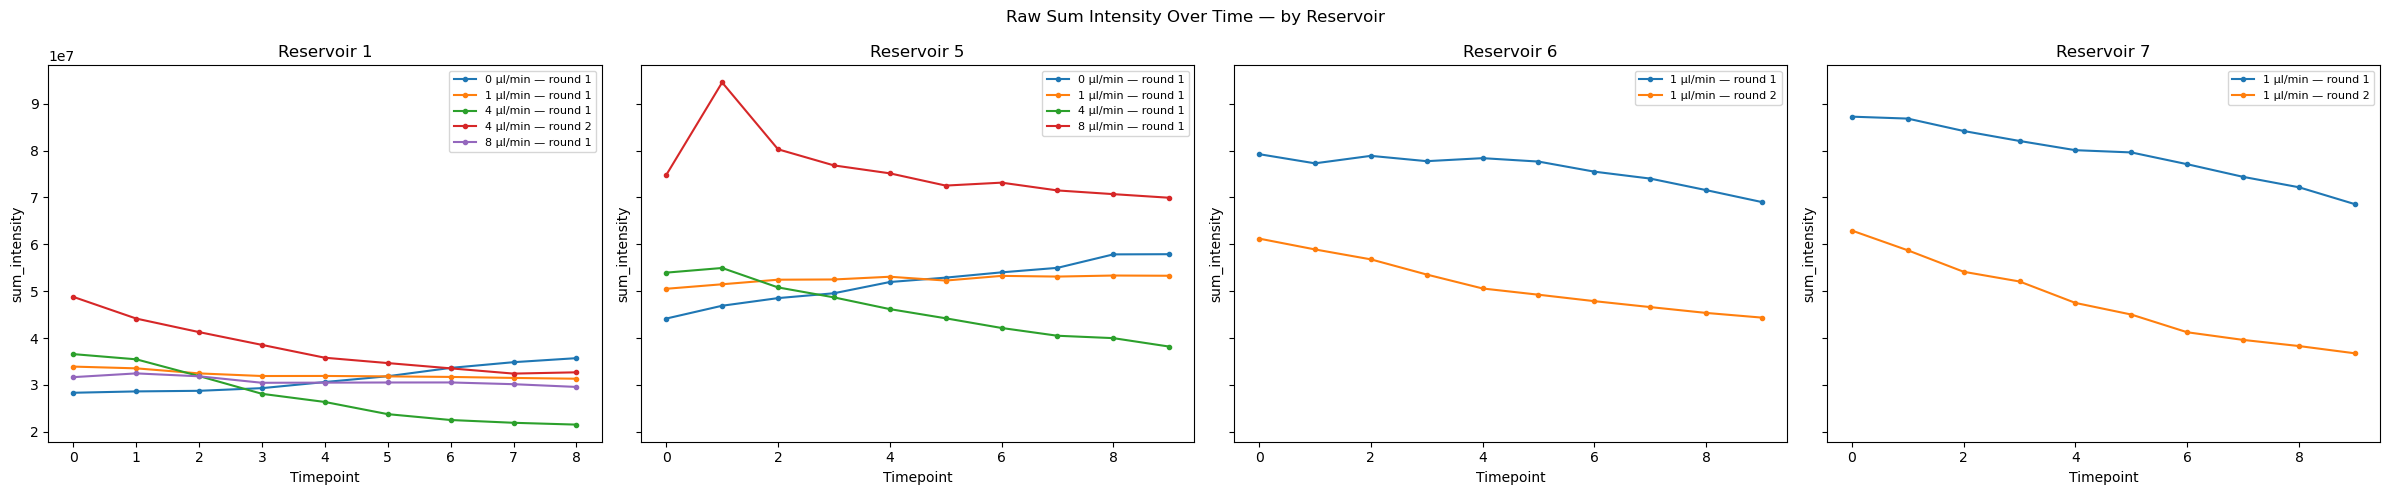

In [ ]:

# ── Plot intensity over time, one subplot per reservoir, line per flow rate ───
def plot_per_reservoir(dframe, value_col, title, out_name):
    reservoirs = sorted(r for r in dframe["reservoir"].dropna().unique())
    if not reservoirs:
        print("No reservoirs found to plot.")
        return
    n = len(reservoirs)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), squeeze=False, sharey=True)
    axes = axes[0]
    for ax, res in zip(axes, reservoirs):
        sub = dframe[dframe["reservoir"] == res]
        seen = set()
        for (flow, rnd, fname), g in sub.groupby(["flow_rate", "round", "file"]):
            g = g.sort_values("timepoint")
            key = (flow, rnd)
            label = f"{flow} µl/min — round {rnd}" if key not in seen else None
            seen.add(key)
            ax.plot(g["timepoint"], g[value_col], marker="o", markersize=3, label=label)
        ax.set_title(f"Reservoir {res}")
        ax.set_xlabel("Timepoint")
        ax.set_ylabel(value_col)
        ax.legend(fontsize=8)
    fig.suptitle(title)
    plt.tight_layout()
    plt.savefig(str(root / out_name), dpi=150, bbox_inches="tight")
    plt.show()

plot_per_reservoir(df, "sum_intensity",
                   "Raw Sum Intensity Over Time — by Reservoir",
                   "plot_intensity_by_reservoir.png")


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# ROLLING-BALL BACKGROUND REMOVAL (ball radius = 20 px) — sum intensity per t
# ══════════════════════════════════════════════════════════════════════════════


BALL_RADIUS = 20  # pixels

def _rolling_ball_subtract(frame):
    """Subtract a rolling-ball background from a (Z, Y, X) or (Y, X) frame."""
    frame = frame.astype(np.float32)
    if frame.ndim == 3:  # (Z, Y, X) — process each Z plane
        out = np.empty_like(frame)
        for z in range(frame.shape[0]):
            out[z] = frame[z] - rolling_ball(frame[z], radius=BALL_RADIUS)
        return np.clip(out, 0, None)
    return np.clip(frame - rolling_ball(frame, radius=BALL_RADIUS), 0, None)

rows_bg = []
for condition, paths in sorted(groups.items()):
    print(f"── {condition} ──")
    for p in paths:
        for sub_label, data in iter_stacks(p):
            file_label = _file_label(p, sub_label)
            if data.ndim not in (3, 4):
                print(f"  SKIP unexpected shape {data.shape}: {file_label}")
                continue
            reservoir = _extract_reservoir(file_label)
            flow_rate = _extract_flow_rate(file_label)
            rnd = _extract_round(file_label)
            n_frames = data.shape[0]
            for t in range(n_frames):
                bg_removed = _rolling_ball_subtract(data[t])
                rows_bg.append({
                    "condition": condition,
                    "file": file_label,
                    "reservoir": reservoir,
                    "flow_rate": flow_rate,
                    "round": rnd,
                    "timepoint": t,
                    "sum_intensity": float(bg_removed.sum()),
                })
            print(f"  {file_label}  rolling-ball r={BALL_RADIUS}px done ({n_frames} frames)  "
                  f"reservoir={reservoir}  flow={flow_rate}ul/min  round={rnd}")

df_bg = pd.DataFrame(rows_bg)
out_csv_bg = root / "sum_intensity_rollingball_bg.csv"
df_bg.to_csv(out_csv_bg, index=False)
print(f"\nSaved {len(df_bg)} rows to:\n  {out_csv_bg}")
df_bg


── Bel / Farid_calcium ──
  18.05.26 fluo8 reservoir 1.lif::Reservoir 1 1ul_min 10min  rolling-ball r=20px done (9 frames)  reservoir=1  flow=1ul/min  round=1
  18.05.26 fluo8 reservoir 1.lif::Reservoir 1 4ul_min 10min  rolling-ball r=20px done (9 frames)  reservoir=1  flow=4ul/min  round=1
  18.05.26 fluo8 reservoir 1.lif::Reservoir 1 0ul_min 10 min  rolling-ball r=20px done (9 frames)  reservoir=1  flow=0ul/min  round=1
  18.05.26 fluo8 reservoir 1.lif::Reservoir 1 4ul_min round 2 10min  rolling-ball r=20px done (9 frames)  reservoir=1  flow=4ul/min  round=2
  18.05.26 fluo8 reservoir 1.lif::Reservoir 1 8ul_min 10min  rolling-ball r=20px done (9 frames)  reservoir=1  flow=8ul/min  round=1
  18.05.26 Fluo8 reservoir 5.lif::Reservoir 5 1ul_min 10min  rolling-ball r=20px done (10 frames)  reservoir=5  flow=1ul/min  round=1
  18.05.26 Fluo8 reservoir 5.lif::Reservoir 5 4ul_min 10min  rolling-ball r=20px done (10 frames)  reservoir=5  flow=4ul/min  round=1
  18.05.26 Fluo8 reservoir 5.lif

,condition,file,reservoir,flow_rate,round,timepoint,sum_intensity
0,Bel / Farid_calcium,18.05.26 fluo8 reservoir 1.lif::Reservoir 1 1u...,1,1,1,0,33794840.0
1,Bel / Farid_calcium,18.05.26 fluo8 reservoir 1.lif::Reservoir 1 1u...,1,1,1,1,33424146.0
2,Bel / Farid_calcium,18.05.26 fluo8 reservoir 1.lif::Reservoir 1 1u...,1,1,1,2,32335712.0
3,Bel / Farid_calcium,18.05.26 fluo8 reservoir 1.lif::Reservoir 1 1u...,1,1,1,3,31788222.0
4,Bel / Farid_calcium,18.05.26 fluo8 reservoir 1.lif::Reservoir 1 1u...,1,1,1,4,31799506.0
...,...,...,...,...,...,...,...
120,Bel / Farid_calcium,18.05.26 Fluo8 reservoir 7.lif::Reservoir 7 1u...,7,1,2,5,44862652.0
121,Bel / Farid_calcium,18.05.26 Fluo8 reservoir 7.lif::Reservoir 7 1u...,7,1,2,6,41106512.0
122,Bel / Farid_calcium,18.05.26 Fluo8 reservoir 7.lif::Reservoir 7 1u...,7,1,2,7,39471448.0
123,Bel / Farid_calcium,18.05.26 Fluo8 reservoir 7.lif::Reservoir 7 1u...,7,1,2,8,38162392.0


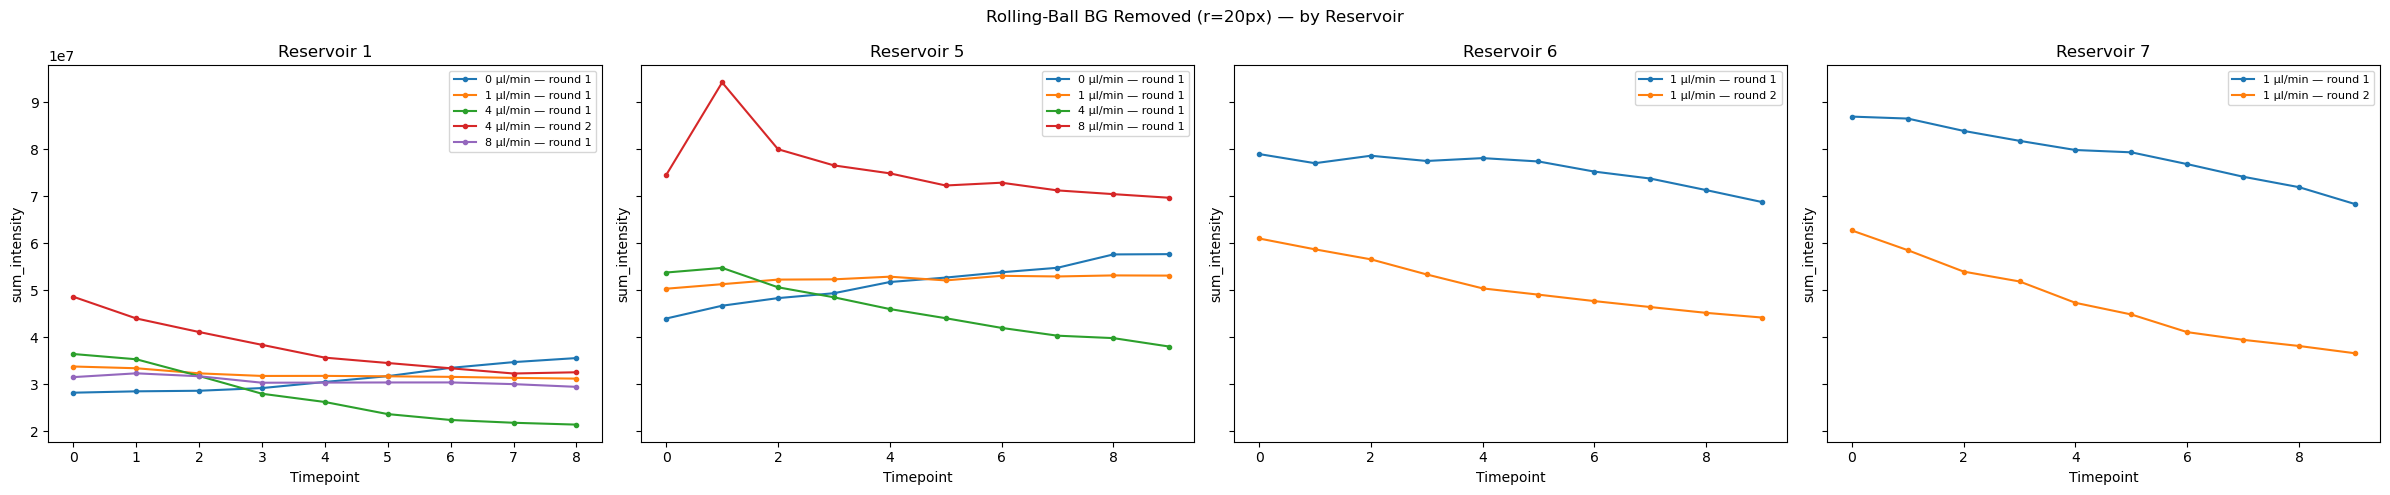

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT: rolling-ball background-removed intensity over time — by reservoir
# ══════════════════════════════════════════════════════════════════════════════
plot_per_reservoir(df_bg, "sum_intensity",
                   f"Rolling-Ball BG Removed (r={BALL_RADIUS}px) — by Reservoir",
                   "plot_intensity_rollingball_by_reservoir.png")
